# Fusion des 4 datasets usinage

Ce notebook charge, nettoie et relie les 4 sources de données :

| # | Dataset | Capteurs | Cible principale |
|---|---------|----------|------------------|
| 1 | **PHM 2010** | Force XYZ · Vibration XYZ · AE (séries temporelles) | Usure VB continue (mm) |
| 2 | **UC Berkeley CNC** | Courant / puissance moteurs (séries temporelles) | worn / unworn (binaire) |
| 3 | **dataset_2** (Exp1/Exp2/Prep) | Rugosité Ra/Rz + Forces Fx/Fy/Fz agrégées | Qualité surface + état outil |
| 4 | **Hauptprogramm** (df1/df2_parsed) | G-code NC, déplacements, énergie par axe | Énergie consommée par commande |

---
### Choix d'architecture : pourquoi une fusion partielle ?

Ces 4 datasets ont des **natures différentes** (séries temporelles brutes vs. mesures agrégées vs. G-code).  
On ne peut pas les empiler naïvement en une seule table — il manquerait 90% des valeurs.  

**Stratégie adoptée :**
- **PHM2010, UC Berkeley, dataset_2** → résumés en **features statistiques** (1 ligne = 1 essai), label usure harmonisé, concaténation avec colonne `source`.
- **Hauptprogramm** → garde sa logique temporelle séquence G-code, mais on en extrait un **vecteur d'énergie par essai** qui peut enrichir les autres.
- Un champ `source` permet toujours de séparer les datasets ou de faire du domain adaptation.

## 0. Imports & configuration des chemins

In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── ADAPTEZ CES CHEMINS à votre arborescence ───────────────────────────────
PATH_PHM         = './dataset_4'          # dossier contenant c1/ c4/ c6/
PATH_UC          = './dataset_1'          # dossier contenant train.csv + experiment_*.csv
PATH_D2_EXP1     = './dataset_2/Exp1.csv'
PATH_D2_EXP2     = './dataset_2/Exp2.csv'
PATH_D2_PREP     = './dataset_2/Prep.csv'
PATH_HAUPT_DF1   = './df1_parsed.csv'     # fichier G-code parsé, programme 1
PATH_HAUPT_DF2   = './df2_parsed.csv'     # fichier G-code parsé, programme 2
# ─────────────────────────────────────────────────────────────────────────────

print('✅ Imports OK')

✅ Imports OK


---
## 1. PHM 2010 — Extraction de features depuis les séries temporelles

**Choix :** chaque fichier CSV contient ~200 000 points à 50 kHz.  
On résume chaque signal en 13 indicateurs statistiques (domaine temporel + énergie + percentiles).  
→ 1 ligne par passe (= par expérience).

In [2]:
COL_NAMES_PHM = ['force_x','force_y','force_z','vib_x','vib_y','vib_z','ae']
SIGNAL_COLS_PHM = ['force_x','force_y','force_z','vib_x','vib_y','vib_z','ae']

def charger_wear_phm(dataset_path):
    """Charge la VB depuis les fichiers c*_wear.csv (valeurs en µm)."""
    wear_maps = {}
    wear_files = sorted(glob.glob(os.path.join(dataset_path, 'c*', 'c*_wear.csv')))
    if not wear_files:
        print('⚠️ Aucun fichier wear PHM trouvé (c*_wear.csv).')
        return wear_maps

    for wf in wear_files:
        cond = os.path.basename(wf).split('_')[0]  # ex: c1
        wdf = pd.read_csv(wf)
        needed = {'cut', 'flute_1', 'flute_2', 'flute_3'}
        if not needed.issubset(wdf.columns):
            print(f'  ⚠️ Colonnes wear manquantes dans {wf}')
            continue

        for c in ['cut', 'flute_1', 'flute_2', 'flute_3']:
            wdf[c] = pd.to_numeric(wdf[c], errors='coerce')
        wdf = wdf.dropna(subset=['cut'])

        # Moyenne des 3 flûtes = VB par passe (en µm)
        vb_um = wdf[['flute_1', 'flute_2', 'flute_3']].mean(axis=1)
        series = pd.Series(vb_um.values, index=wdf['cut'].astype(int).values)
        wear_maps[cond] = series

    print(f'✅ Fichiers wear PHM chargés : {len(wear_maps)} conditions')
    return wear_maps


def charger_phm(dataset_path, col_names):
    records = []
    # Ne charger que les fichiers signaux c_x_yyy.csv (et ignorer *_wear.csv)
    fichiers = sorted(glob.glob(os.path.join(dataset_path, 'c*', 'c*', 'c_*_*.csv')))
    if not fichiers:
        print(f'❌ Aucun CSV signal PHM trouvé dans {dataset_path}')
        return []
    print(f'📄 {len(fichiers)} fichiers signal PHM trouvés...')

    for fp in fichiers:
        try:
            df = pd.read_csv(fp, header=None, names=col_names)
            nom = os.path.basename(fp).replace('.csv', '')   # ex: c_1_001
            parties = nom.split('_')
            condition = f'c{parties[1]}'                     # c1 / c4 / c6
            num_passe = int(parties[2])                      # 1..315
            records.append({
                'filepath': fp,
                'condition': condition,
                'passe': num_passe,
                'data': df
            })
        except Exception as e:
            print(f'  ⚠️ Erreur sur {fp}: {e}')

    print(f'✅ {len(records)} fichiers chargés')
    return records


def extraire_features_signal(df_signal, signal_cols):
    """13 features statistiques par signal — méthode commune à PHM et UC Berkeley."""
    features = {}
    for col in signal_cols:
        if col not in df_signal.columns:
            continue
        sig = df_signal[col].dropna().values.astype(float)
        if len(sig) == 0:
            continue
        features[f'{col}_mean']   = np.mean(sig)
        features[f'{col}_std']    = np.std(sig)
        features[f'{col}_rms']    = np.sqrt(np.mean(sig**2))
        features[f'{col}_max']    = np.max(np.abs(sig))
        features[f'{col}_p2p']    = np.ptp(sig)
        features[f'{col}_skew']   = skew(sig)
        features[f'{col}_kurt']   = kurtosis(sig)
        features[f'{col}_crest']  = np.max(np.abs(sig)) / (np.sqrt(np.mean(sig**2)) + 1e-10)
        features[f'{col}_shape']  = np.sqrt(np.mean(sig**2)) / (np.mean(np.abs(sig)) + 1e-10)
        features[f'{col}_energy'] = np.sum(sig**2)
        features[f'{col}_p25']    = np.percentile(sig, 25)
        features[f'{col}_p75']    = np.percentile(sig, 75)
        features[f'{col}_iqr']    = np.percentile(sig, 75) - np.percentile(sig, 25)
    return features


wear_maps_phm = charger_wear_phm(PATH_PHM)
raw_phm = charger_phm(PATH_PHM, COL_NAMES_PHM)

rows_phm = []
for rec in raw_phm:
    feats = extraire_features_signal(rec['data'][SIGNAL_COLS_PHM], SIGNAL_COLS_PHM)
    feats['condition_exp'] = rec['condition']
    feats['passe']         = rec['passe']

    # Récupérer VB depuis le fichier wear (en µm), puis convertir en mm
    vb_um = np.nan
    if rec['condition'] in wear_maps_phm and rec['passe'] in wear_maps_phm[rec['condition']].index:
        vb_um = wear_maps_phm[rec['condition']].loc[rec['passe']]
    vb_mm = vb_um / 1000 if pd.notna(vb_um) else np.nan

    feats['vb_mm'] = vb_mm
    if pd.isna(vb_mm):
        feats['tool_condition'] = 'unknown'
    else:
        feats['tool_condition'] = 'worn' if vb_mm >= 0.2 else 'unworn'
    feats['source'] = 'PHM2010'
    rows_phm.append(feats)

df_phm = pd.DataFrame(rows_phm)
print(f'\n✅ PHM2010 : {df_phm.shape[0]} essais × {df_phm.shape[1]} colonnes')
print(df_phm['tool_condition'].value_counts(dropna=False))
print('VB (mm) stats :', df_phm['vb_mm'].describe().to_dict())
df_phm.head(3)

✅ Fichiers wear PHM chargés : 3 conditions
📄 1890 fichiers signal PHM trouvés...
✅ 1890 fichiers chargés

✅ PHM2010 : 1890 essais × 96 colonnes
tool_condition
unknown    945
unworn     917
worn        28
Name: count, dtype: int64
VB (mm) stats : {'count': 945.0, 'mean': 0.1136980190265887, 'std': 0.03752933027523618, 'min': 0.02421603668333333, '25%': 0.09184737072666667, '50%': 0.10591255826666666, '75%': 0.13449303029999998, 'max': 0.2159422376333333}


,force_x_mean,force_x_std,force_x_rms,force_x_max,force_x_p2p,force_x_skew,force_x_kurt,force_x_crest,force_x_shape,force_x_energy,...,ae_shape,ae_energy,ae_p25,ae_p75,ae_iqr,condition_exp,passe,vb_mm,tool_condition,source
0,0.400857,0.842468,0.932973,3.744,6.245,0.115205,-0.245189,4.012978,1.251618,1.108930e+05,...,1.274877,0.633771,-0.002,0.001,0.003,c1,1,0.039644,unworn,PHM2010
1,1.028151,1.864977,2.129609,8.427,12.646,0.606325,0.022639,3.957065,1.345953,9.854836e+05,...,1.054356,359.414850,0.031,0.044,0.013,c1,2,0.041736,unworn,PHM2010
2,1.776092,2.672088,3.208514,11.534,17.528,0.605046,0.073317,3.594811,1.332573,2.248208e+06,...,1.040287,1047.931778,0.056,0.072,0.016,c1,3,0.043704,unworn,PHM2010


---
## 2. UC Berkeley CNC — Extraction de features

**Choix :** on filtre uniquement les phases d'usinage actif (Layer X Up/Down) pour éviter que
les phases de positionnement rapide (G0) ne noient le signal utile.  
On applique les **mêmes 13 features** que PHM2010 pour que les deux datasets partagent un espace commun sur les signaux dynamiques — même si les capteurs sont différents (courant vs force).

In [3]:
UC_SIGNALS = ['S1_OutputCurrent','S1_OutputPower','S1_CurrentFeedback',
              'X1_OutputCurrent','Y1_OutputCurrent','Z1_CurrentFeedback']

ACTIVE_LABELS = ['Layer 1 Up','Layer 1 Down','Layer 2 Up',
                 'Layer 2 Down','Layer 3 Up','Layer 3 Down']

train_path = os.path.join(PATH_UC, 'train.csv')
train_uc   = pd.read_csv(train_path)

exp_files = sorted(glob.glob(os.path.join(PATH_UC, 'experiment_*.csv')))
print(f'📄 {len(exp_files)} expériences trouvées')

rows_uc = []
for f in exp_files:
    eid = int(os.path.basename(f).split('_')[1].split('.')[0])
    df_exp = pd.read_csv(f)

    # Récupérer le label depuis train.csv
    label_row = train_uc[train_uc['No'] == eid]
    if label_row.empty:
        continue
    tool_cond = label_row['tool_condition'].values[0]

    # Garder uniquement les phases actives
    active = df_exp[df_exp['Machining_Process'].isin(ACTIVE_LABELS)]

    feats = extraire_features_signal(active, UC_SIGNALS)
    feats['condition_exp'] = f'exp_{eid:02d}'
    feats['passe']         = eid
    feats['vb_mm']         = np.nan          # non disponible dans ce dataset
    feats['tool_condition']= tool_cond       # 'worn' / 'unworn'
    feats['source']        = 'UC_Berkeley'
    rows_uc.append(feats)

df_uc = pd.DataFrame(rows_uc)
print(f'\n✅ UC Berkeley : {df_uc.shape[0]} essais × {df_uc.shape[1]} colonnes')
print(df_uc['tool_condition'].value_counts())
df_uc.head(3)

📄 18 expériences trouvées

✅ UC Berkeley : 18 essais × 83 colonnes
tool_condition
worn      10
unworn     8
Name: count, dtype: int64


,S1_OutputCurrent_mean,S1_OutputCurrent_std,S1_OutputCurrent_rms,S1_OutputCurrent_max,S1_OutputCurrent_p2p,S1_OutputCurrent_skew,S1_OutputCurrent_kurt,S1_OutputCurrent_crest,S1_OutputCurrent_shape,S1_OutputCurrent_energy,...,Z1_CurrentFeedback_shape,Z1_CurrentFeedback_energy,Z1_CurrentFeedback_p25,Z1_CurrentFeedback_p75,Z1_CurrentFeedback_iqr,condition_exp,passe,vb_mm,tool_condition,source
0,319.984864,2.274940,319.992951,324.0,18.0,-0.792285,0.930131,1.012522,1.000025,101473929.0,...,0.0,0.0,0.0,0.0,0.0,exp_01,1,NaN,unworn,UC_Berkeley
1,326.399439,5.097041,326.439234,332.0,40.0,-0.744330,0.720890,1.017035,1.000122,113915391.0,...,0.0,0.0,0.0,0.0,0.0,exp_02,2,NaN,unworn,UC_Berkeley
2,322.621269,4.745209,322.656164,330.0,40.0,0.041330,0.597940,1.022761,1.000108,111602704.0,...,0.0,0.0,0.0,0.0,0.0,exp_03,3,NaN,unworn,UC_Berkeley


---
## 3. dataset_2 (Exp1 / Exp2 / Prep) — Agrégation des mesures de surface

**Choix :** chaque `Run_ID` a 6 répétitions de mesure (colonne `R_measurement`).  
On en fait la **moyenne** pour obtenir 1 ligne par essai, cohérent avec les autres datasets.

Ce dataset est le seul à avoir des **métriques de rugosité surface** directes (Ra, Rz, Rsk, Rku…).  
Ces features sont gardées telles quelles — elles n'ont pas d'équivalent dans les autres datasets  
et apparaîtront en NaN dans la table fusionnée, ce qui est normal et attendu.

In [4]:
def charger_dataset2(*paths):
    frames = []
    for p in paths:
        if os.path.exists(p):
            frames.append(pd.read_csv(p))
        else:
            print(f'  ⚠️ Fichier introuvable : {p}')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


df_d2_raw = charger_dataset2(PATH_D2_EXP1, PATH_D2_EXP2, PATH_D2_PREP)
print(f'📄 dataset_2 brut : {df_d2_raw.shape}')

if df_d2_raw.empty:
    raise ValueError("dataset_2 est vide: vérifiez PATH_D2_EXP1, PATH_D2_EXP2, PATH_D2_PREP")
if 'Run_ID' not in df_d2_raw.columns:
    raise KeyError("La colonne 'Run_ID' est absente de dataset_2")

# Colonnes à agréger
# — rugosité : moyenne des 6 mesures
# — forces et paramètres de coupe : identiques pour toutes les répétitions → first()
agg_dict = {
    'Ra':'mean','Rz':'mean','Rsk':'mean','Rku':'mean',
    'RSm':'mean','Rt':'mean',
    'Fx':'first','Fy':'first','Fz':'first','F':'first',
    'ap':'first','vc':'first','f':'first',
    'Condition':'first','TCond':'first',
    'Machined_length':'first','Tool_ID':'first',
    'Experiment':'first','Replica':'first'
}

# Forcer en numérique les colonnes destinées à la moyenne pour éviter mean() sur des strings
mean_cols = [c for c, agg in agg_dict.items() if agg == 'mean' and c in df_d2_raw.columns]
for c in mean_cols:
    df_d2_raw[c] = pd.to_numeric(df_d2_raw[c], errors='coerce')

# Garder seulement les colonnes présentes
agg_dict = {k:v for k,v in agg_dict.items() if k in df_d2_raw.columns}

df_d2 = df_d2_raw.groupby('Run_ID').agg(agg_dict).reset_index()

# --- Harmonisation du label outil ---
# Condition : 0 = outil neuf, valeur positive = outil usé
if 'Condition' in df_d2.columns:
    cond_num = pd.to_numeric(df_d2['Condition'], errors='coerce')
    df_d2['tool_condition'] = np.where(cond_num.fillna(0) > 0, 'worn', 'unworn')
else:
    df_d2['tool_condition'] = 'unknown'

df_d2['vb_mm']         = np.nan   # pas de mesure VB directe
df_d2['condition_exp'] = df_d2['Run_ID']
df_d2['passe']         = range(len(df_d2))
df_d2['source']        = 'dataset_2'

print(f'\n✅ dataset_2 agrégé : {df_d2.shape[0]} essais × {df_d2.shape[1]} colonnes')
print(df_d2['tool_condition'].value_counts(dropna=False))
df_d2.head(3)

📄 dataset_2 brut : (824, 28)

✅ dataset_2 agrégé : 103 essais × 25 colonnes
tool_condition
worn      102
unworn      1
Name: count, dtype: int64


,Run_ID,Ra,Rz,Rsk,Rku,RSm,Rt,Fx,Fy,Fz,...,TCond,Machined_length,Tool_ID,Experiment,Replica,tool_condition,vb_mm,condition_exp,passe,source
0,1_021_B1_1_h,0.233833,1.475167,-0.322833,2.905833,71.133333,1.714333,55.44,41.60,19.53,...,0.0,12,21,1.0,1,worn,NaN,1_021_B1_1_h,0,dataset_2
1,1_021_B1_2_g,0.675000,2.393667,0.198500,1.596500,100.083333,2.617333,69.13,50.07,20.51,...,0.0,12,21,1.0,1,worn,NaN,1_021_B1_2_g,1,dataset_2
2,1_021_B1_3_i,0.829833,3.518333,1.039000,2.796667,130.550000,3.736167,84.61,56.61,24.09,...,0.0,12,21,1.0,1,worn,NaN,1_021_B1_3_i,2,dataset_2


---
## 4. Hauptprogramm — Énergie totale par programme G-code

**Choix :** ce dataset a une logique très différente : la cible est l'**énergie consommée par axe**  
et non l'état d'outil. On ne peut pas le mettre dans la même table de classification.  

**Ce qu'on en extrait pour la fusion :**  
On somme l'énergie totale par programme (df1 et df2) et on crée un **vecteur d'empreinte énergétique**
qui pourrait servir de feature dans les autres modèles (ex : plus d'énergie sur l'axe X = usure différente).

Le dataset Hauptprogramm est aussi conservé **tel quel** dans un DataFrame séparé
pour les tâches de prédiction énergétique.

In [5]:
ENERGY_COLS = ['ENERGY|x','ENERGY|y','ENERGY|z','ENERGY|S','ENERGY|T']

def charger_haupt(path1, path2):
    frames = {}
    for nom, p in [('prog1', path1), ('prog2', path2)]:
        if os.path.exists(p):
            frames[nom] = pd.read_csv(p, index_col=['Unnamed: 0'] if 'Unnamed: 0' in
                                       pd.read_csv(p, nrows=0).columns else None)
        else:
            print(f'  ⚠️ Fichier introuvable : {p}')
    return frames


haupt_frames = charger_haupt(PATH_HAUPT_DF1, PATH_HAUPT_DF2)

# Résumé énergétique par programme
rows_haupt = []
for prog_id, df_h in haupt_frames.items():
    feats = {'source': 'Hauptprogramm', 'condition_exp': prog_id,
             'passe': 0, 'vb_mm': np.nan, 'tool_condition': 'unknown'}
    for col in ENERGY_COLS:
        if col in df_h.columns:
            feats[f'haupt_{col.replace("|","_")}_sum']  = df_h[col].sum()
            feats[f'haupt_{col.replace("|","_")}_mean'] = df_h[col].mean()
            feats[f'haupt_{col.replace("|","_")}_std']  = df_h[col].std()
    rows_haupt.append(feats)

df_haupt = pd.DataFrame(rows_haupt)
print(f'✅ Hauptprogramm : {df_haupt.shape[0]} programmes × {df_haupt.shape[1]} colonnes')
print('   (conservé séparément — logique cible différente)')
df_haupt.head()

  ⚠️ Fichier introuvable : ./df1_parsed.csv
  ⚠️ Fichier introuvable : ./df2_parsed.csv
✅ Hauptprogramm : 0 programmes × 0 colonnes
   (conservé séparément — logique cible différente)


""


---
## 5. Fusion — PHM2010 + UC Berkeley + dataset_2

**Pourquoi ces 3 et pas les 4 ?**  
PHM2010, UC Berkeley et dataset_2 partagent tous un **label d'état d'outil** (worn/unworn)  
et des **paramètres de coupe** (vc, f, ap), ce qui rend la fusion cohérente pour une tâche de classification.  
Hauptprogramm a une cible différente (énergie) et est laissé à part.

Après la fusion, les colonnes propres à chaque source seront **NaN** dans les autres —  
c'est délibéré. Les algorithmes comme `HistGradientBoostingClassifier` ou XGBoost gèrent  
les NaN nativement. Pour Random Forest, on utilisera une imputation par médiane.

In [6]:
# Colonnes méta communes à conserver dans tous les datasets
META_COLS = ['source','condition_exp','passe','vb_mm','tool_condition']

def preparer_pour_fusion(df, meta_cols):
    """Vérifie que les colonnes méta sont présentes et retourne le DataFrame prêt."""
    for col in meta_cols:
        if col not in df.columns:
            df[col] = np.nan
    return df


df_phm_f   = preparer_pour_fusion(df_phm.copy(),    META_COLS)
df_uc_f    = preparer_pour_fusion(df_uc.copy(),     META_COLS)
df_d2_f    = preparer_pour_fusion(df_d2.copy(),     META_COLS)

# Concaténation — pandas aligne les colonnes, NaN là où elles n'existent pas
df_fused = pd.concat([df_phm_f, df_uc_f, df_d2_f], ignore_index=True, sort=False)

print('=== Résumé du dataset fusionné ===')
print(f'Shape total        : {df_fused.shape}')
print(f'Colonnes           : {df_fused.shape[1]}')
print()
print('Répartition par source et label :')
print(df_fused.groupby(['source','tool_condition']).size().to_string())
print()
nan_summary = df_fused.isnull().sum()
nan_summary = nan_summary[nan_summary > 0].sort_values(ascending=False)
print(f'Colonnes avec NaN : {len(nan_summary)} / {df_fused.shape[1]}')
print('Top 10 colonnes les plus creuses :')
print(nan_summary.head(10))

=== Résumé du dataset fusionné ===
Shape total        : (2011, 194)
Colonnes           : 194

Répartition par source et label :
source       tool_condition
PHM2010      unknown           945
             unworn            917
             worn               28
UC_Berkeley  unworn              8
             worn               10
dataset_2    unworn              1
             worn              102

Colonnes avec NaN : 190 / 194
Top 10 colonnes les plus creuses :
Z1_CurrentFeedback_skew      2011
Z1_CurrentFeedback_kurt      2011
S1_CurrentFeedback_iqr       1993
X1_OutputCurrent_mean        1993
S1_CurrentFeedback_shape     1993
S1_CurrentFeedback_energy    1993
X1_OutputCurrent_max         1993
X1_OutputCurrent_p2p         1993
X1_OutputCurrent_skew        1993
X1_OutputCurrent_kurt        1993
dtype: int64


---
## 6. Sauvegarde

On sauvegarde :
- `dataset_fused.csv` — les 3 datasets avec label d'usure
- `dataset_haupt.csv` — Hauptprogramm séparé (énergie par programme)

In [7]:
df_fused.to_csv('dataset_fused.csv', index=False)
df_haupt.to_csv('dataset_haupt.csv', index=False)

print(f'✅ dataset_fused.csv  → {df_fused.shape[0]} lignes, {df_fused.shape[1]} colonnes')
print(f'✅ dataset_haupt.csv  → {df_haupt.shape[0]} lignes, {df_haupt.shape[1]} colonnes')

✅ dataset_fused.csv  → 2011 lignes, 194 colonnes
✅ dataset_haupt.csv  → 0 lignes, 0 colonnes


---
## 7. Exploration visuelle du dataset fusionné

### 7a. Distribution des labels par source

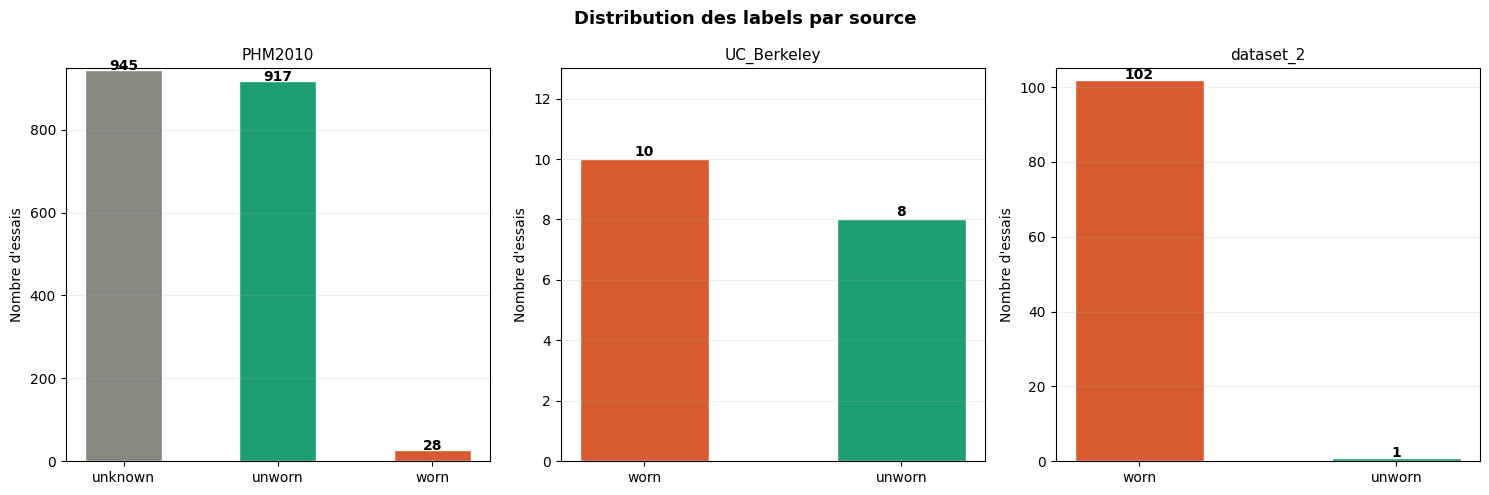

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution des labels par source', fontsize=13, fontweight='bold')

colors = {'worn':'#D85A30','unworn':'#1D9E75','unknown':'#888780'}

for ax, src in zip(axes, ['PHM2010','UC_Berkeley','dataset_2']):
    sub = df_fused[df_fused['source'] == src]['tool_condition'].value_counts()
    ax.bar(sub.index, sub.values,
           color=[colors.get(c,'gray') for c in sub.index],
           edgecolor='white', width=0.5)
    ax.set_title(src, fontsize=11)
    ax.set_ylabel('Nombre d\'essais')
    for i, (idx, val) in enumerate(sub.items()):
        ax.text(i, val + 0.1, str(val), ha='center', fontweight='bold')
    ax.set_ylim(0, sub.max() + 3)
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('fusion_labels.png', dpi=150, bbox_inches='tight')
plt.show()

### 7b. Disponibilité des features (carte de NaN)

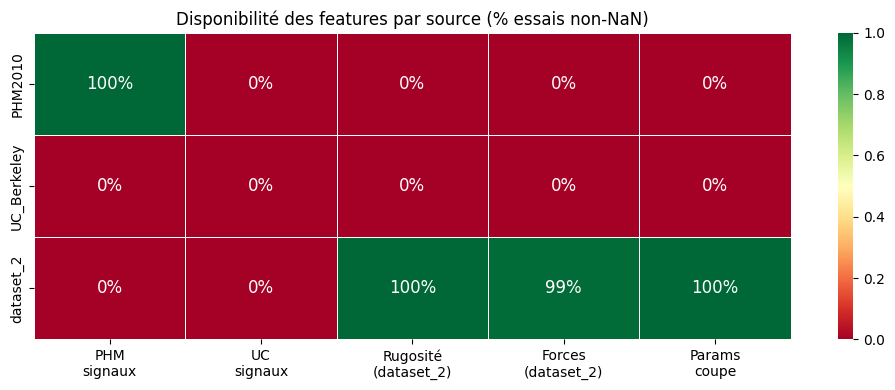


Lecture : 100% = features toujours remplies dans cette source, 0% = toujours NaN


In [9]:
# On construit une heatmap source × groupe de features
source_order = ['PHM2010','UC_Berkeley','dataset_2']

# Groupes de features par préfixe
def groupe_feature(col):
    if any(col.startswith(s) for s in ['force_','vib_','ae_']):
        return 'PHM\nsignaux'
    if any(col.startswith(s) for s in ['S1_','X1_','Y1_','Z1_']):
        return 'UC\nsignaux'
    if col in ['Ra','Rz','Rsk','Rku','RSm','Rt']:
        return 'Rugosité\n(dataset_2)'
    if col in ['Fx','Fy','Fz','F']:
        return 'Forces\n(dataset_2)'
    if col in ['ap','vc','f']:
        return 'Params\ncoupe'
    return None

feature_groups = ['PHM\nsignaux','UC\nsignaux','Rugosité\n(dataset_2)','Forces\n(dataset_2)','Params\ncoupe']
disponibilite  = pd.DataFrame(index=source_order, columns=feature_groups)

for src in source_order:
    sub = df_fused[df_fused['source'] == src]
    for grp in feature_groups:
        cols_grp = [c for c in df_fused.columns if groupe_feature(c) == grp]
        if not cols_grp:
            disponibilite.loc[src, grp] = 0
        else:
            ratio = sub[cols_grp].notna().all(axis=1).mean()
            disponibilite.loc[src, grp] = round(ratio, 2)

disponibilite = disponibilite.astype(float)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(disponibilite, annot=True, fmt='.0%', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size':12})
ax.set_title('Disponibilité des features par source (% essais non-NaN)', fontsize=12)
plt.tight_layout()
plt.savefig('fusion_disponibilite.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nLecture : 100% = features toujours remplies dans cette source, 0% = toujours NaN')

### 7c. Corrélation inter-datasets sur les features communes

In [10]:
# Features communes = celles qui ne sont pas 100% NaN dans AU MOINS 2 sources
def disponible_dans_n_sources(col, df, sources, n=2):
    count = sum(df[df['source']==s][col].notna().any() for s in sources)
    return count >= n

feat_communes = [
    c for c in df_fused.columns
    if c not in META_COLS
    and disponible_dans_n_sources(c, df_fused, source_order, n=2)
    and pd.api.types.is_numeric_dtype(df_fused[c])
]

print(f'Features présentes dans ≥2 sources : {len(feat_communes)}')
print(feat_communes[:20])

if feat_communes:
    corr_data = df_fused[feat_communes + ['tool_condition']].copy()
    corr_data['label_num'] = (corr_data['tool_condition'] == 'worn').astype(int)
    corr = corr_data[feat_communes + ['label_num']].corr()['label_num'].drop('label_num')
    top10 = corr.abs().nlargest(10)

    plt.figure(figsize=(10, 5))
    colors_bar = ['#D85A30' if corr[f] > 0 else '#1D9E75' for f in top10.index]
    plt.barh(top10.index[::-1], corr[top10.index[::-1]], color=colors_bar[::-1])
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Corrélation avec label worn (1) / unworn (0)')
    plt.title('Top 10 features communes les plus discriminantes')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('fusion_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Aucune feature commune trouvée — vérifiez les noms de colonnes.')

Features présentes dans ≥2 sources : 0
[]
Aucune feature commune trouvée — vérifiez les noms de colonnes.


---
## 8. Préparation pour le Machine Learning

### Choix du modèle : `HistGradientBoostingClassifier`

Ce modèle est recommandé pour les datasets fusionnés avec NaN car :
- Il **gère les NaN nativement** (pas besoin d'imputation)
- Il est robuste aux features de scales très différents
- La colonne `source` est encodée comme feature → le modèle apprend les biais inter-datasets

La colonne `source` est volontairement laissée comme feature : 
elle permet au modèle de corriger les biais de chaque dataset.
Si on la retire, on fait du **domain-blind learning** — possible aussi, mais moins précis.

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Exclure les essais sans label clair
df_ml = df_fused[df_fused['tool_condition'].isin(['worn','unworn'])].copy()

# Encoder la source comme feature numérique
le_source = LabelEncoder()
df_ml['source_enc'] = le_source.fit_transform(df_ml['source'])

# Features : tout ce qui est numérique, hors méta
EXCLUDE = set(META_COLS + ['source_enc']) - {'source_enc'}
feat_ml = [
    c for c in df_ml.columns
    if c not in EXCLUDE
    and pd.api.types.is_numeric_dtype(df_ml[c])
    and c != 'tool_condition'
] + ['source_enc']

X = df_ml[feat_ml]
y = (df_ml['tool_condition'] == 'worn').astype(int)

print(f'X shape : {X.shape}')
print(f'Worn : {y.sum()}, Unworn : {(1-y).sum()}')

# Cross-validation stratifiée (respecte les proportions worn/unworn)
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = HistGradientBoostingClassifier(random_state=42, max_iter=200)

scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted')
print(f'\nF1 (weighted) par fold : {scores.round(3)}')
print(f'Moyenne : {scores.mean():.3f} ± {scores.std():.3f}')

X shape : (1066, 188)
Worn : 140, Unworn : 926

F1 (weighted) par fold : [0.969 0.976 0.981 0.991 0.995]
Moyenne : 0.982 ± 0.010


### Importance des features — par source

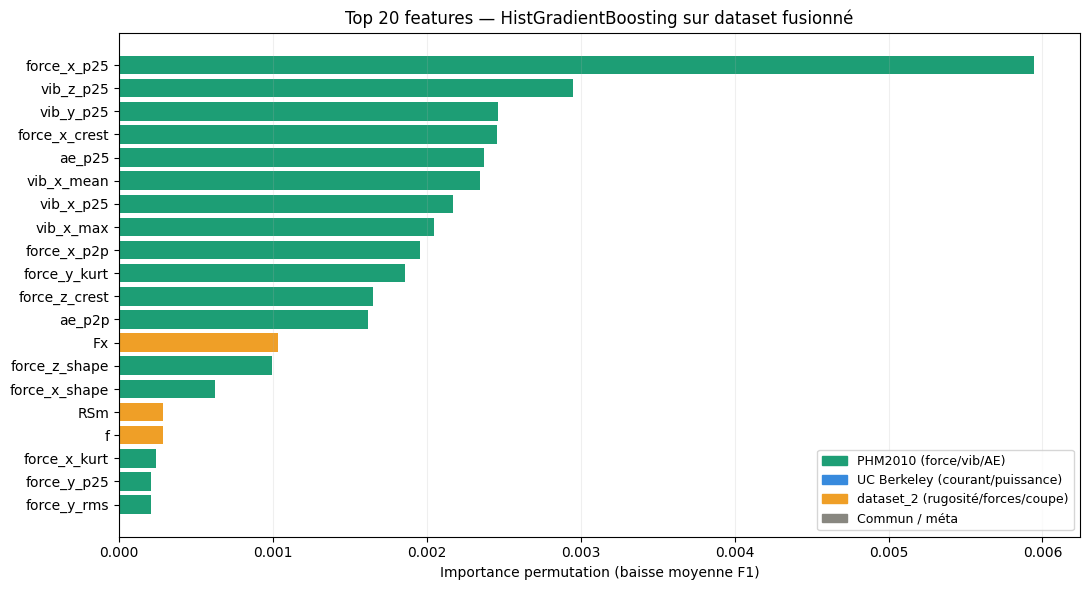

In [12]:
# Entraîner sur tout le dataset pour visualiser les importances
model.fit(X, y)

# HistGradientBoostingClassifier n'expose pas feature_importances_ :
# on utilise l'importance par permutation.
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    model, X, y,
    n_repeats=10,
    random_state=42,
    scoring='f1_weighted'
)
importances = pd.Series(perm.importances_mean, index=feat_ml).sort_values(ascending=False)

# Colorer par source d'origine
def couleur_feature(nom):
    if any(nom.startswith(s) for s in ['force_','vib_','ae_']):
        return '#1D9E75'
    if any(nom.startswith(s) for s in ['S1_','X1_','Y1_','Z1_']):
        return '#378ADD'
    if nom in ['Ra','Rz','Rsk','Rku','RSm','Rt','Fx','Fy','Fz','F','ap','vc','f']:
        return '#EF9F27'
    return '#888780'

top20 = importances.head(20)
colors_imp = [couleur_feature(f) for f in top20.index]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_imp[::-1])
ax.set_xlabel('Importance permutation (baisse moyenne F1)')
ax.set_title('Top 20 features — HistGradientBoosting sur dataset fusionné')
ax.grid(True, alpha=0.2, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#1D9E75', label='PHM2010 (force/vib/AE)'),
    Patch(color='#378ADD', label='UC Berkeley (courant/puissance)'),
    Patch(color='#EF9F27', label='dataset_2 (rugosité/forces/coupe)'),
    Patch(color='#888780', label='Commun / méta'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fusion_importances.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Prochaines étapes possibles

| Objectif | Approche |
|----------|----------|
| **Améliorer la généralisation cross-dataset** | Leave-One-Source-Out CV : entraîner sur 2 sources, tester sur la 3e |
| **Exploiter la VB continue (PHM2010)** | Régression HistGradientBoostingRegressor sur `vb_mm` (les NaN des autres sources sont ignorés) |
| **Intégrer Hauptprogramm** | Jointure sur `condition_exp` si les programmes NC correspondent à des essais identifiables dans les autres datasets |
| **Réduire les NaN** | MICE (imputation multivariée) ou modèle spécifique par source puis empilement (stacking) |
| **Alignement de domaine** | CORAL, MMD ou adversarial domain adaptation pour réduire les biais inter-datasets |